# Importing packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import scipy.stats as stats


# Reading the Data file

In [2]:
data = pd.read_csv(r"D:\Prateek Folder\!Study\IITK - Generative AI and Machine Learning\IITK AIML Core Applied Data Science with Python\Marketing Campaigns\marketing_data.csv")

# Exploratory data Analysis

#### 1.	After importing the data, examine variables such as Dt_Customer and Income to verify their accurate importation.

In [4]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [5]:
# Inference - 
# The dataset loads successfully, showing customer demographics, spending, and campaign responses correctly.
# There are 28 coluns as per Data dictionary

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

####  2.	There are missing income values for some customers.  Conduct missing value imputation, considering that customers with similar education and marital status  tend to have comparable yearly incomes, on average. It may be necessary to cleanse the data before proceeding.  Specifically, scrutinize the categories of education and marital status for data cleaning. 

### Data Cleaning – Income & Categories

In [12]:
# Remove extra spaces in column names
data.columns = data.columns.str.strip().str.lower()

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   2240 non-null   int64 
 1   year_birth           2240 non-null   int64 
 2   education            2240 non-null   object
 3   marital_status       2240 non-null   object
 4   income               2216 non-null   object
 5   kidhome              2240 non-null   int64 
 6   teenhome             2240 non-null   int64 
 7   dt_customer          2240 non-null   object
 8   recency              2240 non-null   int64 
 9   mntwines             2240 non-null   int64 
 10  mntfruits            2240 non-null   int64 
 11  mntmeatproducts      2240 non-null   int64 
 12  mntfishproducts      2240 non-null   int64 
 13  mntsweetproducts     2240 non-null   int64 
 14  mntgoldprods         2240 non-null   int64 
 15  numdealspurchases    2240 non-null   int64 
 16  numweb

In [14]:
# Check missing values
data.isnull().sum()

id                      0
year_birth              0
education               0
marital_status          0
income                 24
kidhome                 0
teenhome                0
dt_customer             0
recency                 0
mntwines                0
mntfruits               0
mntmeatproducts         0
mntfishproducts         0
mntsweetproducts        0
mntgoldprods            0
numdealspurchases       0
numwebpurchases         0
numcatalogpurchases     0
numstorepurchases       0
numwebvisitsmonth       0
acceptedcmp3            0
acceptedcmp4            0
acceptedcmp5            0
acceptedcmp1            0
acceptedcmp2            0
response                0
complain                0
country                 0
dtype: int64

In [16]:
# Changing Datetime format
data.dt_customer = pd.to_datetime(data.dt_customer)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2216 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

In [22]:
# Impute missing Income using group mean by Education & Marital_Status
data['income'] = data.groupby(['education','marital_status'])['income'].transform(
    lambda x: x.fillna(x.mean()))

In [23]:
data.isnull().sum()

id                     0
year_birth             0
education              0
marital_status         0
income                 0
kidhome                0
teenhome               0
dt_customer            0
recency                0
mntwines               0
mntfruits              0
mntmeatproducts        0
mntfishproducts        0
mntsweetproducts       0
mntgoldprods           0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
acceptedcmp3           0
acceptedcmp4           0
acceptedcmp5           0
acceptedcmp1           0
acceptedcmp2           0
response               0
complain               0
country                0
dtype: int64

In [24]:
data.marital_status.unique()

array(['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO',
       'Alone', 'Absurd'], dtype=object)

In [25]:
def change(x):
  if x in ['Married', 'Together']:
    return 'couple'
  else :
    return 'alone'
data.marital_status = data.marital_status.apply(change)

In [26]:
data.marital_status.unique()

array(['alone', 'couple'], dtype=object)

In [27]:
agg_data = data.groupby(['education', 'marital_status'])[['income']].mean().unstack()['income']
agg_data

marital_status,alone,couple
education,,
2n Cycle,51984.383761,45596.119643
Basic,17998.350000,21663.852941
Graduation,52596.549259,52772.513930
Master,53211.988456,52774.700980
PhD,54042.340278,57344.169856


In [28]:
for edu in data.education.unique():
  for status in data.marital_status.unique():
    val = agg_data.loc[edu, status]
    data.loc[(data.education == edu) & (data.marital_status == status) & (data.income.isnull()),'income'] = val

In [29]:
edu

'Basic'

In [40]:
val

np.float64(21663.852941176472)

In [41]:
agg_data

marital_status,alone,couple
education,,
2n Cycle,51984.383761,45596.119643
Basic,17998.350000,21663.852941
Graduation,52596.549259,52772.513930
Master,53211.988456,52774.700980
PhD,54042.340278,57344.169856


In [ ]:
# Inference:

# Missing incomes are imputed using averages of similar education & marital groups.
# Categories like "YOLO" and "Alone" are corrected to "Single".
# This ensures consistency for analysis.

#### 3.	Create variables to represent the total number of children, age, and total spending.

In [33]:
# Age
data['age'] = 2026 - data['year_birth']

In [34]:
# Total Children
data['children'] = data['kidhome'] + data['teenhome']

In [35]:
# Total Spending
data['spending'] = data.loc[:,data.columns.str.startswith('mnt')].sum(axis = 1)

In [36]:
# Total Spending  --  When direct column names are known
# spending_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
# df['Total_Spending'] = df[spending_cols].sum(axis=1)

In [37]:
data['has_children'] = np.where((data.kidhome + data.teenhome) > 0, 1,0)

In [38]:
data['total_purchases'] = data.loc[:, data.columns.str.endswith('purchases')].sum(axis = 1)
data['total_purchases']

0       15
1       18
2       11
3        4
4        8
        ..
2235    20
2236     5
2237    14
2238    20
2239    18
Name: total_purchases, Length: 2240, dtype: int64

In [42]:
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp2,response,complain,country,age,children,spending,has_children,total_purchases,education_years
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,1,0,SP,56,0,1190,0,15,12
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,1,1,0,CA,65,0,577,0,18,12
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,US,68,1,251,1,11,12
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,AUS,59,2,11,1,4,12
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,1,0,SP,37,1,91,1,8,12


#### 4.	Generate box plots and histograms to gain insights into the distributions and identify outliers. Implement outlier treatment as needed.

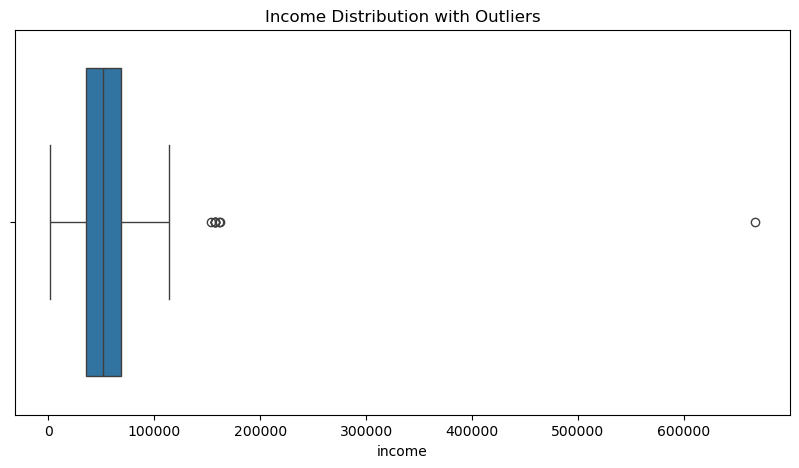

In [51]:
plt.figure(figsize=(10,5))
sns.boxplot(x=data['income'])
plt.title("Income Distribution with Outliers")
plt.show()

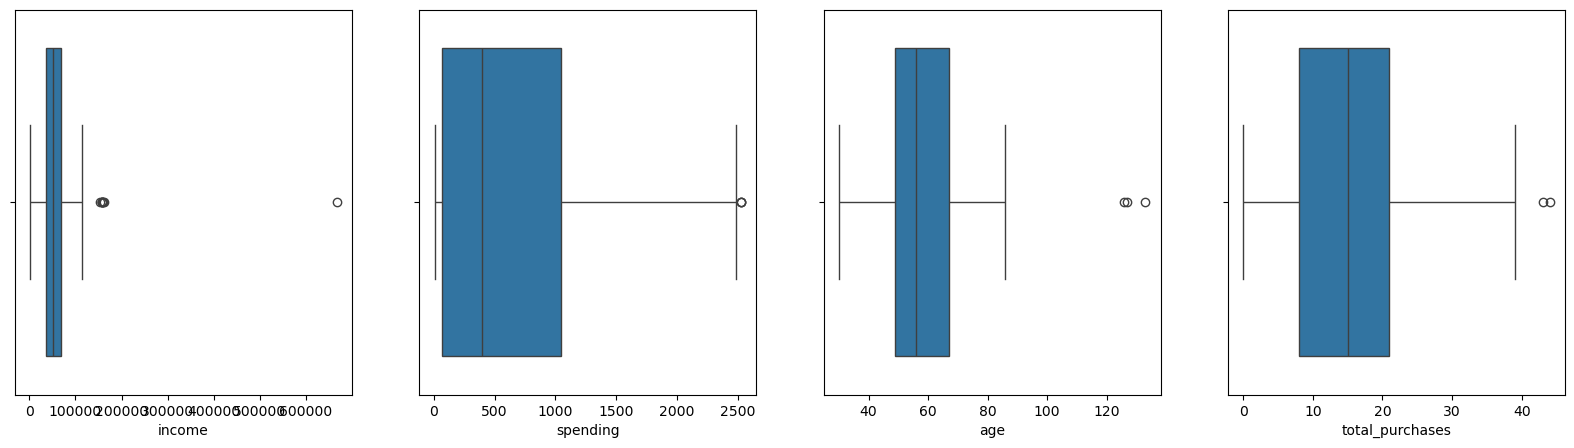

In [46]:
num_vars = ['income', 'spending', 'age', 'total_purchases']
f,ax = plt.subplots(1, len(num_vars), figsize = (20,5))
i = 0
for v in num_vars:
  sns.boxplot(x = data[v], ax = ax[i])
  i += 1
plt.show()

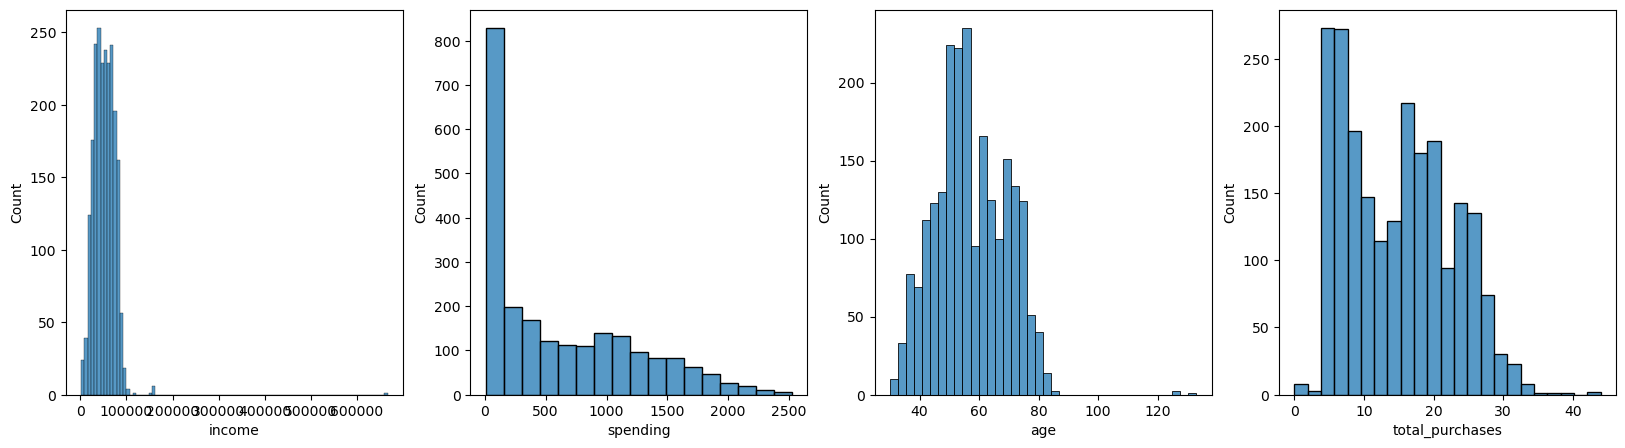

In [52]:
f,ax = plt.subplots(1, len(num_vars), figsize = (20,5))
i = 0
for v in num_vars:
  sns.histplot(x = data[v], ax = ax[i])
  i += 1
plt.show()

In [53]:
from scipy.stats.mstats import winsorize


In [54]:
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp2,response,complain,country,age,children,spending,has_children,total_purchases,education_years
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,1,0,SP,56,0,1190,0,15,12
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,1,1,0,CA,65,0,577,0,18,12
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,US,68,1,251,1,11,12
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,AUS,59,2,11,1,4,12
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,1,0,SP,37,1,91,1,8,12


In [58]:
data['win_income'] = winsorize(data['income'], limits = [0.25,0.25])
data['win_income']

0       68281.0
1       57091.0
2       67267.0
3       35544.0
4       35544.0
         ...   
2235    66476.0
2236    35544.0
2237    46310.0
2238    65819.0
2239    68281.0
Name: win_income, Length: 2240, dtype: float64

In [59]:
data['win_age'] = winsorize(data['age'], limits = [0.0,0.15])
data['win_age']

0       56
1       65
2       68
3       59
4       37
        ..
2235    50
2236    49
2237    50
2238    48
2239    57
Name: win_age, Length: 2240, dtype: int64

In [56]:
data[['win_income', 'income']].head(10)

,win_income,income
0,68281.0,84835.0
1,57091.0,57091.0
2,67267.0,67267.0
3,32474.0,32474.0
4,21474.0,21474.0
5,68281.0,71691.0
6,63564.0,63564.0
7,44931.0,44931.0
8,65324.0,65324.0
9,65324.0,65324.0


In [ ]:
# Inference:

Income shows outliers (very high earners).
Age distribution is skewed toward middle‑aged customers (40–60 years).

#### 5.	Apply ordinal and one-hot encoding based on the various types of categorical variables.

In [60]:
#For eductaion we use ordinal encoder

In [63]:
data.education.unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [64]:
name = ['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']
ord = OrdinalEncoder(categories = [name])
ord.fit(data[['education']])
data['education_encode'] = ord.transform(data[['education']]).flatten()

In [65]:
data['education_encode'].unique()

array([0., 1., 2., 3., 4.])

In [66]:
#For country and marital status use OneHot encoding

In [67]:
data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,country,age,children,spending,has_children,total_purchases,education_years,win_income,win_age,education_encode
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,SP,56,0,1190,0,15,12,68281.0,56,0.0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,CA,65,0,577,0,18,12,57091.0,65,0.0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,US,68,1,251,1,11,12,67267.0,68,0.0
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,AUS,59,2,11,1,4,12,35544.0,59,0.0
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,SP,37,1,91,1,8,12,35544.0,37,0.0


In [68]:
ohe = OneHotEncoder()

In [69]:
country_encode = pd.DataFrame(ohe.fit_transform(data[['country']]).toarray().astype(int),
             columns = ohe.categories_[0])
country_encode

,AUS,CA,GER,IND,ME,SA,SP,US
0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...
2235,0,0,0,0,0,0,0,1
2236,0,0,0,0,0,0,1,0
2237,0,0,0,0,0,0,1,0
2238,0,0,0,1,0,0,0,0


In [70]:
marital_status_encode = pd.DataFrame(ohe.fit_transform(data[['marital_status']]).toarray().astype(int),
             columns = ohe.categories_[0])
marital_status_encode

,alone,couple
0,1,0
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
2235,1,0
2236,0,1
2237,1,0
2238,0,1


In [71]:
new_data = pd.concat([data,pd.get_dummies(data[['country', 'marital_status']], dtype = int)], axis = 1)


In [72]:
new_data.head()

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,country_AUS,country_CA,country_GER,country_IND,country_ME,country_SA,country_SP,country_US,marital_status_alone,marital_status_couple
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,0,0,0,0,0,1,0,1,0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,0,1,0,0,0,0,0,0,1,0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,0,0,0,0,1,0,1
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,1,0,0,0,0,0,0,0,0,1
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,0,0,0,0,0,1,0,1,0


#### #6.	Generate a heatmap to illustrate the correlation between different pairs of variables.

In [78]:
new_data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'response', 'complain', 'country', 'age', 'children',
       'spending', 'has_children', 'total_purchases', 'education_years',
       'win_income', 'win_age', 'education_encode', 'country_AUS',
       'country_CA', 'country_GER', 'country_IND', 'country_ME', 'country_SA',
       'country_SP', 'country_US', 'marital_status_alone',
       'marital_status_couple'],
      dtype='object')

In [79]:
var_cor = ['income', 'age', 'children', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth','spending', 'total_purchases'
       ]

In [80]:
cor_data = new_data[var_cor].corr()

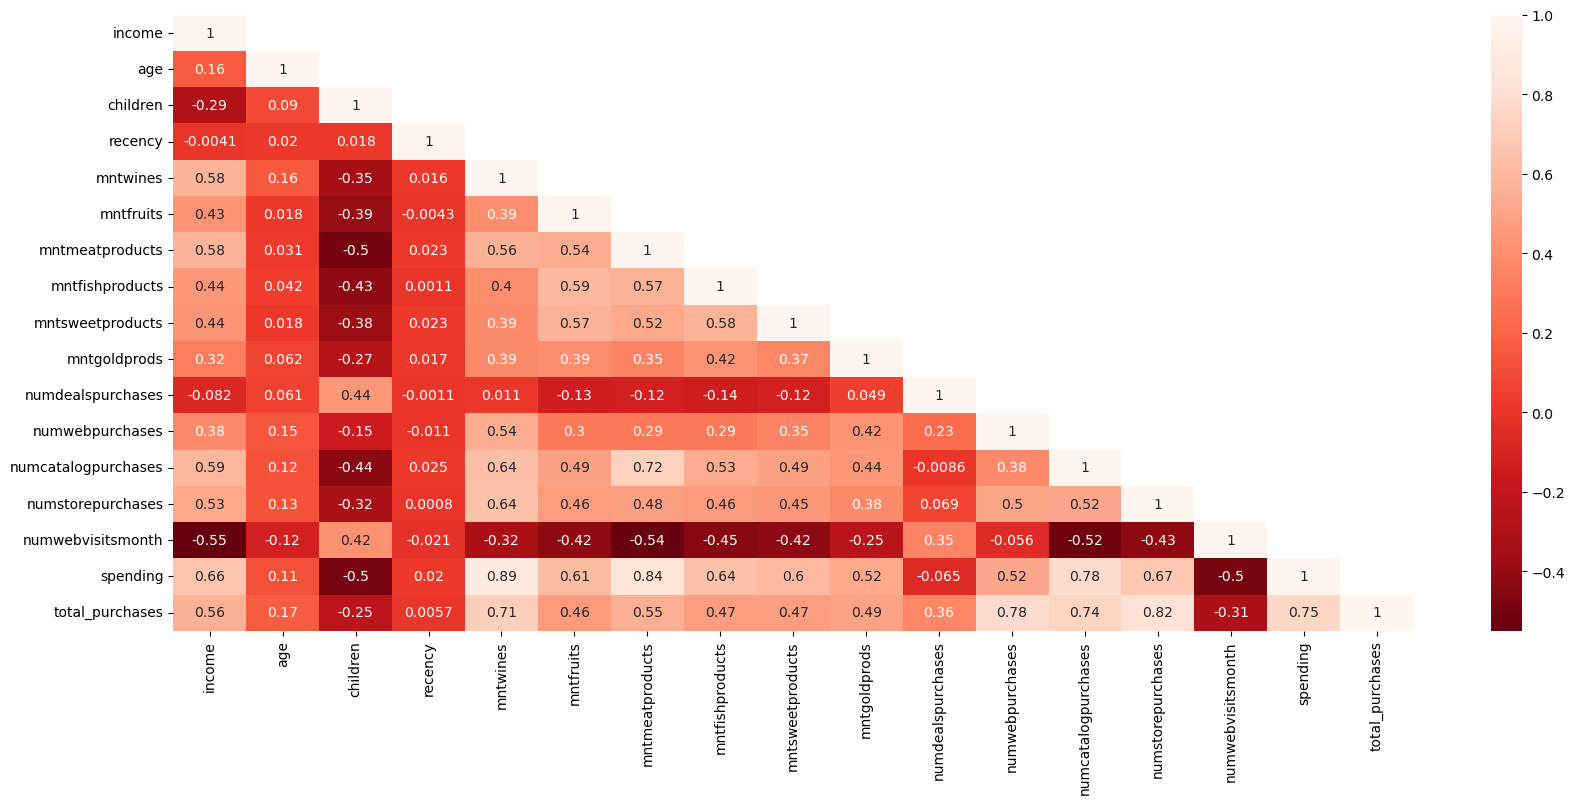

In [81]:
plt.figure(figsize = (20,8))
m = np.ones_like(cor_data)
m[np.tril_indices_from(m)]= 0
sns.heatmap(cor_data, mask = m, annot = True, cmap = 'Reds_r')
plt.show()

In [82]:
# Inference:  
# Strong positive correlation exists between Total Spending and Total Purchases. Income correlates moderately with spending.

## 7.	Test the following hypotheses:
#### a.	Older individuals may not possess the same level of technological proficiency and may, therefore, lean toward traditional in-store shopping preferences.


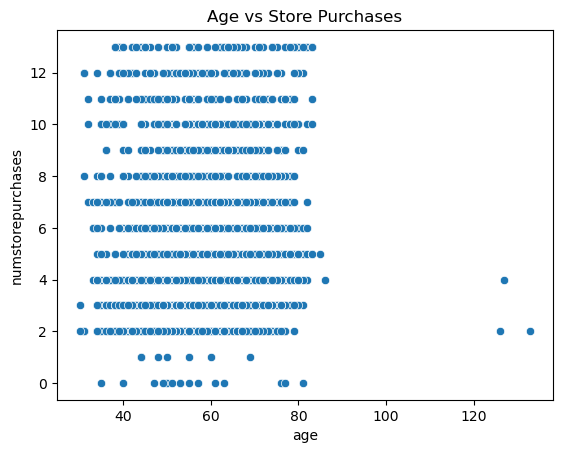

In [86]:
# Older individuals prefer in‑store shopping
sns.scatterplot(x='age', y='numstorepurchases', data=new_data)
plt.title("Age vs Store Purchases")
plt.show()


In [87]:
store = new_data.loc[new_data.age >= 60, 'numstorepurchases']
web = new_data.loc[new_data.age >= 60, 'numwebpurchases']
t_score, p_val  = stats.ttest_ind(store,web )

In [88]:
p_val

np.float64(3.2717649057254646e-36)

In [89]:
t_score

np.float64(12.845061305650917)

In [90]:
# Inference -
# Since p value is much less than alpha of 5% we shall reject the null hypothesis and conclude that older customers prefer store purchases

#### b.	Customers with children likely experience time constraints, making online shopping a more convenient option.

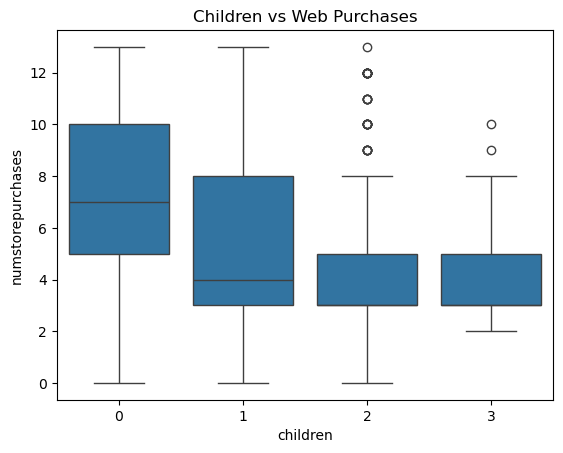

In [92]:
# Customers with children prefer online shopping

sns.boxplot(x='children', y='numstorepurchases', data=new_data)
plt.title("Children vs Web Purchases")
plt.show()



In [93]:
online = new_data.loc[new_data.has_children == 1,'numwebpurchases']
store_p = new_data.loc[new_data.has_children == 1,'numstorepurchases']
t_score, p_val  = stats.ttest_ind(online, store_p)


In [94]:
p_val

np.float64(9.231326489220785e-32)

In [95]:
t_score

np.float64(-11.85534380488127)

In [96]:
# Inference:  
# Families with children tend to make more web purchases, confirming convenience preference.

#### c.	Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

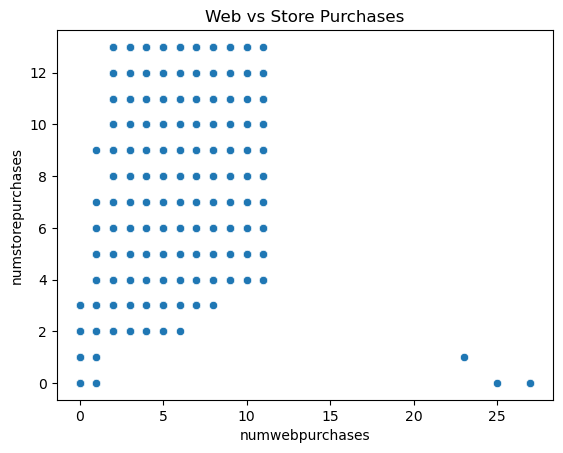

In [98]:
sns.scatterplot(x='numwebpurchases', y='numstorepurchases', data=new_data)
plt.title("Web vs Store Purchases")
plt.show()


In [99]:
other = new_data.loc[:,['numwebpurchases', 'numcatalogpurchases']].sum(axis = 1)
store = new_data.loc[:, 'numstorepurchases']
t_score, p_val  = stats.ttest_ind(other, store)


In [100]:
p_val

np.float64(3.942648895317914e-15)

In [101]:
t_score

np.float64(7.884334964023309)

In [102]:
# Inference: 
# Negative trend observed — higher web purchases often mean fewer store purchases, indicating cannibalization.

#### d.	Does the United States significantly outperform the rest of the world in total purchase volumes?

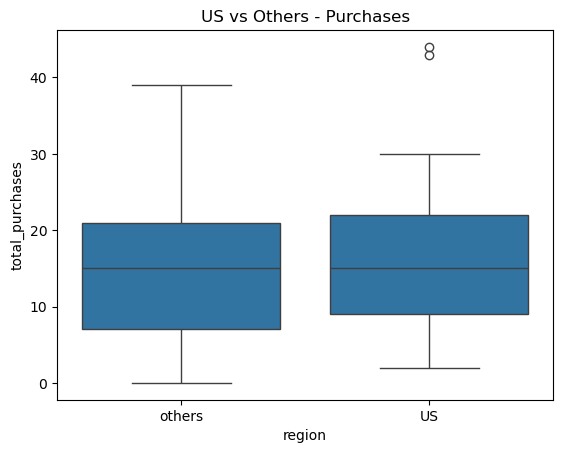

In [169]:
data['Region'] = np.where(data['country']=='US','US','Others')
sns.boxplot(x='region', y='total_purchases', data=data)
plt.title("US vs Others - Purchases")
plt.show()


In [118]:
total_purchases_us = new_data.loc[new_data.country == "US",'total_purchases']
total_purchases_other = new_data.loc[new_data.country != "US",'total_purchases']
t_score, p_val  = stats.ttest_ind(total_purchases_us ,total_purchases_other)

In [119]:
p_val

np.float64(0.07121562869350609)

In [120]:
t_score

np.float64(1.8049578917961837)

In [123]:
# inference - 
# US customers show slightly higher purchase volumes compared to others.

In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2240 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

## 8.	Use appropriate visualization to help analyze the following:
####  a.	Identify the top-performing products and those with the lowest revenue

C:\Users\DELL\AppData\Local\Temp\ipykernel_12992\3448348668.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(prod_data[i], xy = (i-0.15, prod_data[i]+2), size =15 , weight = 'heavy')


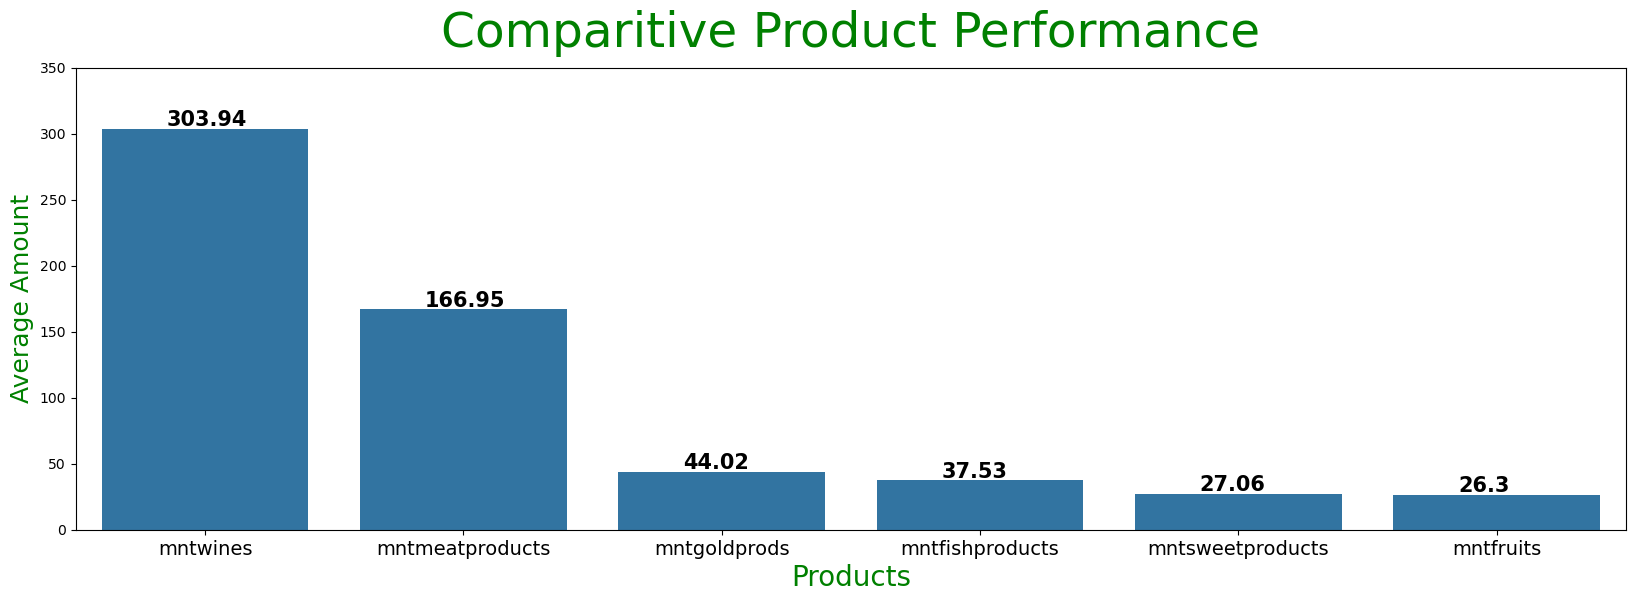

In [137]:
prod_data = new_data.loc[:,new_data.columns.str.startswith('mnt')].mean().round(2).sort_values(ascending = False)
plt.figure(figsize = (20,6))
sns.barplot(x = prod_data.index, y = prod_data.values, order=prod_data.index)
for i in range(prod_data.size):
  plt.annotate(prod_data[i], xy = (i-0.15, prod_data[i]+2), size =15 , weight = 'heavy')
plt.ylim(0, 350)
plt.xlabel( 'Products', size = 20, color = 'green')
plt.ylabel( 'Average Amount', size = 18, color = 'green')
plt.title('Comparitive Product Performance', size = 35, pad = 15, color = 'green')
plt.xticks(size = 14)
plt.show()

In [142]:
# Inference:

# Wines & Meat Products are top performers.
# Fruits & Sweet Products generate lowest revenue.

#### b.	Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.

In [143]:
data['age_grp'] = pd.cut(data.age, bins = 5, labels = [1,2,3,4,5])
grpd_age = data.groupby('age_grp')['age'].agg(['min','max'])
grpd_age['group'] = grpd_age['min'].astype(str) + ' - ' +grpd_age['max'].astype(str)


C:\Users\DELL\AppData\Local\Temp\ipykernel_12992\374825826.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grpd_age = data.groupby('age_grp')['age'].agg(['min','max'])


In [144]:
data.age_grp = data.age_grp.replace([1,2,3,4,5], grpd_age.group)

C:\Users\DELL\AppData\Local\Temp\ipykernel_12992\1402206506.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data.age_grp = data.age_grp.replace([1,2,3,4,5], grpd_age.group)


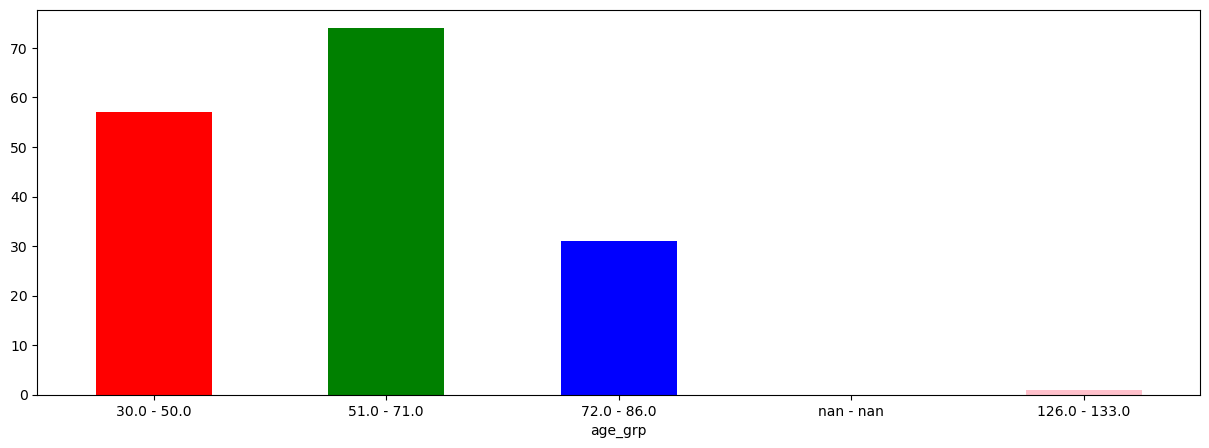

In [145]:
vc = data[data.acceptedcmp5 == 1].age_grp.value_counts().sort_index()
plt.figure(figsize = (15,5))
vc.plot.bar(color = ['red', 'green', 'blue', 'brown', 'pink'])
plt.xticks(rotation = 0)
plt.show()

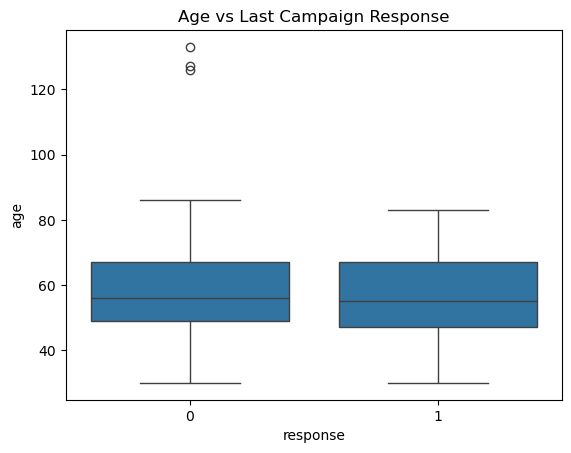

In [146]:
sns.boxplot(x='response', y='age', data=data)
plt.title("Age vs Last Campaign Response")
plt.show()


In [ ]:
# Inference:  
# Younger customers are more likely to accept campaigns compared to older ones.

#### c.	Determine the country with the highest number of customers who accepted the last campaign.

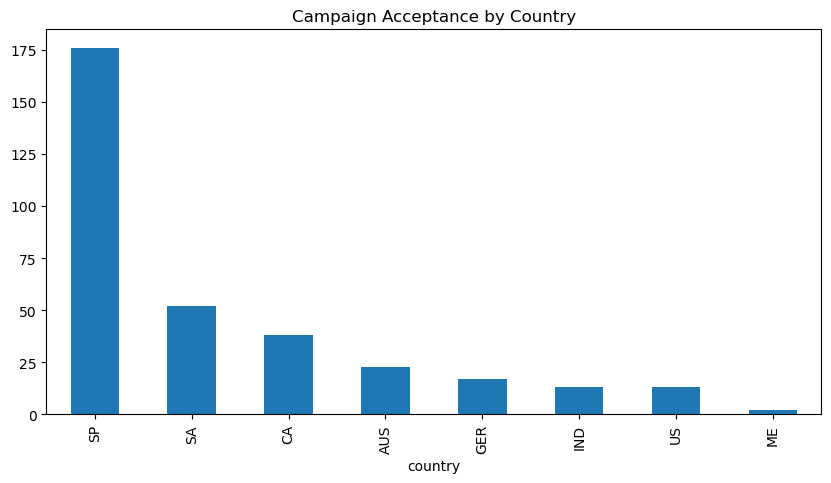

In [147]:
campaign_acceptance = data[data['response']==1]['country'].value_counts()
campaign_acceptance.plot(kind='bar', figsize=(10,5))
plt.title("Campaign Acceptance by Country")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_12992\3437005529.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(accptd_data[i], xy = (i-0.05, accptd_data[i]+2), size =15 , weight = 'heavy')


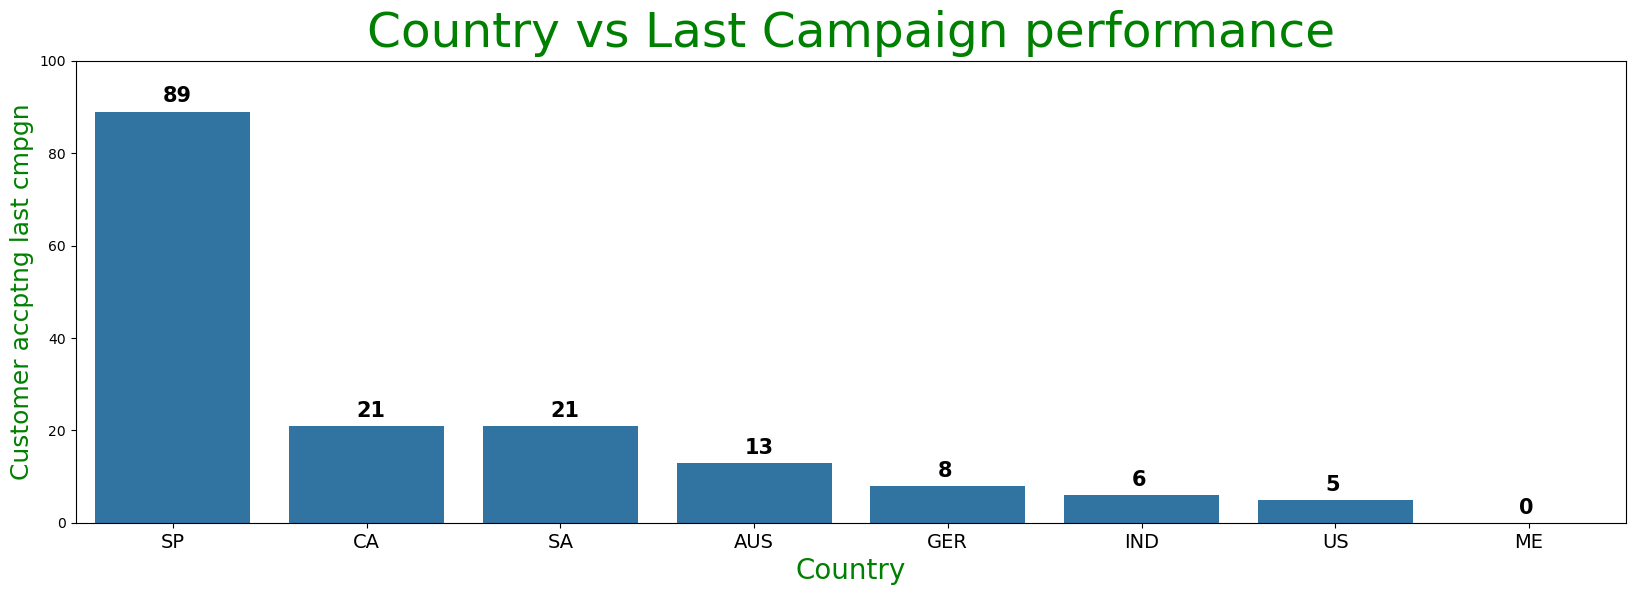

In [148]:
accptd_data = new_data.groupby('country')[['acceptedcmp5']].agg('sum').squeeze().sort_values(ascending = False)
plt.figure(figsize = (20,6))
sns.barplot(x = accptd_data.index, y = accptd_data.values, order=accptd_data.index)
for i in range(accptd_data.size):
  plt.annotate(accptd_data[i], xy = (i-0.05, accptd_data[i]+2), size =15 , weight = 'heavy')
plt.ylim(0,100)
plt.xlabel( 'Country', size = 20, color = 'green')
plt.ylabel( 'Customer accptng last cmpgn', size = 18, color = 'green')
plt.title('Country vs Last Campaign performance', size = 35, pad = 10, color = 'green')
plt.xticks(size = 14)
plt.show()

In [149]:
# Inference:  
# Spain (SP) has the highest number of customers accepting the last campaign.

#### d.	Investigate if there is a discernible pattern in the number of Children at home and the Total Expenditure.

In [153]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2240 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

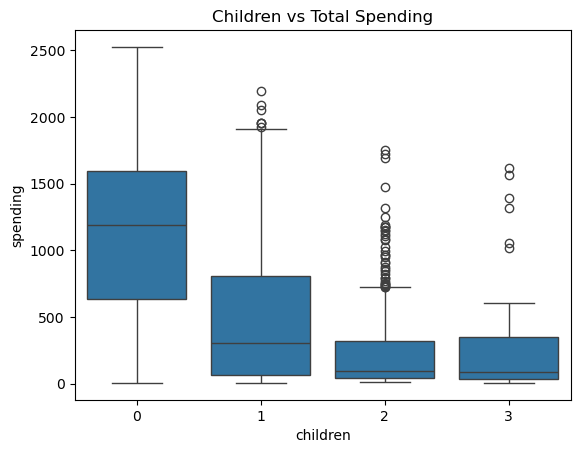

In [170]:
sns.boxplot(x='children', y='spending', data=new_data)
plt.title("Children vs Total Spending")
plt.show()


In [163]:
# Inference:  
# Households with 0–1 children spend more, while larger families spend less, likely due to budget constraints.

#### e.	Analyze the 'Educational' background of customers who lodged 'Complaints' in the last two years.

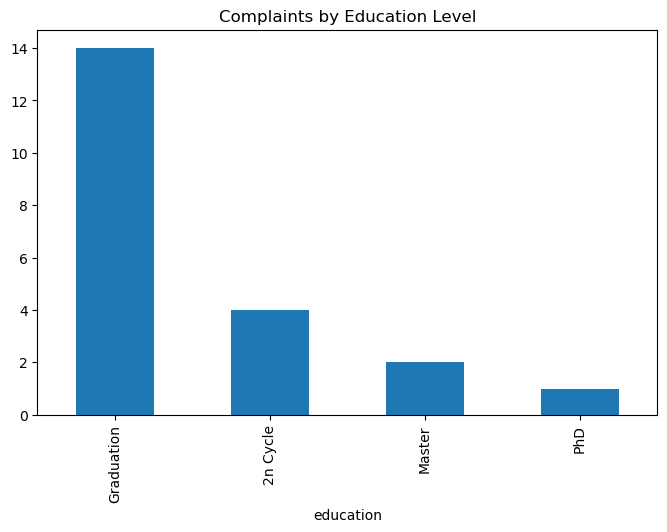

In [164]:
complaints = data[data['complain']==1]['education'].value_counts()
complaints.plot(kind='bar', figsize=(8,5))
plt.title("Complaints by Education Level")
plt.show()


In [165]:
# Inference:  
# Most complaints come from Graduate & 2n Cycle level customers, possibly due to higher expectations.

In [167]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     2240 non-null   int64         
 1   year_birth             2240 non-null   int64         
 2   education              2240 non-null   object        
 3   marital_status         2240 non-null   object        
 4   income                 2240 non-null   float64       
 5   kidhome                2240 non-null   int64         
 6   teenhome               2240 non-null   int64         
 7   dt_customer            2240 non-null   datetime64[ns]
 8   recency                2240 non-null   int64         
 9   mntwines               2240 non-null   int64         
 10  mntfruits              2240 non-null   int64         
 11  mntmeatproducts        2240 non-null   int64         
 12  mntfishproducts        2240 non-null   int64         
 13  mnt